Imports

In [1]:
import pandas as pd
import Orange
import pickle
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


from Orange.preprocess import Discretize, Impute, Randomize, Normalize


Preparing the database

In [2]:
print("Loading dataset...")
df = pd.read_csv("database/ai_student_impact_dataset.csv")

df = df.drop(columns = ['Student_ID','Post_Semester_GPA'])

if 'Paid_Subscription' in df.columns:
    df['Paid_Subscription'] = df['Paid_Subscription'].astype(str)
    
print("Final format dataset:")
print(df.shape)
print("Distribution target (Burnout_Risk_Level):")
print(df['Burnout_Risk_Level'].value_counts())

#Save
df.to_csv("database/new_dataset_burnout.csv", index=False)
print("Dataset saved in database/new_dataset_burnout.csv")

Loading dataset...
Final format dataset:
(50000, 14)
Distribution target (Burnout_Risk_Level):
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64
Dataset saved in database/new_dataset_burnout.csv


Separating the data into training and testing sets for the model CN2

In [3]:

print("Separating the data into training and testing sets for the model CN2... (80/20 split)")

data = pd.read_csv("database/new_dataset_burnout.csv")

data_train, data_test = train_test_split(
    data,
    test_size = 0.2,
    random_state = 42,
    stratify = df['Burnout_Risk_Level']
)

data_train.to_csv("database/train_dataset_burnout.csv", index=False)
data_test.to_csv("database/test_dataset_burnout.csv", index=False)
print(f"Data saved in database/train_dataset_burnout.csv and database/test_dataset_burnout.csv")


print(f"Training dataset shape: {data_train.shape} | Testing dataset shape: {data_test.shape}")

    
def loading_in_orange(path):
    data = Orange.data.Table(path)
    domain = data.domain
    new_domain = Orange.data.Domain(list(domain.attributes[:-1]), domain.attributes[-1])
    return Orange.data.Table.from_table(new_domain, data)


train_data = loading_in_orange('database/train_dataset_burnout.csv')
test_data = loading_in_orange('database/test_dataset_burnout.csv')

Separating the data into training and testing sets for the model CN2... (80/20 split)
Data saved in database/train_dataset_burnout.csv and database/test_dataset_burnout.csv
Training dataset shape: (40000, 14) | Testing dataset shape: (10000, 14)


Training the model CN2

In [4]:
path_model = "models/cn2_classifier_burnout_2.pkl"

if os.path.exists(path_model):
    print(f"Model already exists in {path_model}. Loading the model...")
    with open(path_model, 'rb') as archive:
        cn2_classifier = pickle.load(archive)
else:
    print("Training the model CN2...")
    cn2_learner = Orange.classification.rules.CN2Learner()

    #hyperparameters
    cn2_learner.rule_finder.search_algorithm.beam_width = 15
    cn2_learner.rule_finder.search_strategy.constrain_continuous = True
    
    cn2_learner.rule_finder.general_validator.max_rule_length = 10
    cn2_learner.rule_finder.quality_measure = Orange.classification.rules.LaplaceAccuracyEvaluator()
    cn2_learner.rule_finder.general_validator.min_covered_examples = int(train_data.X.shape[0] * 0.01)

    cn2_classifier = cn2_learner(train_data)

    print("Training has been completed")
    # save model
    with open(path_model, 'wb') as archive:
        pickle.dump(cn2_classifier, archive)
        
    print("**** First 3 rules of the model ****")
    for rule in cn2_classifier.rule_list[:3]:
        print(rule)

Model already exists in models/cn2_classifier_burnout_2.pkl. Loading the model...


Evaluating the model...
Model loaded: models/cn2_classifier_burnout_1.pkl
Total rules: 98
Classification Report:
              precision    recall  f1-score   support

        High       0.61      0.45      0.52      2497
      Medium       0.48      0.59      0.53      4229
         Low       0.52      0.47      0.50      3274

    accuracy                           0.52     10000
   macro avg       0.54      0.51      0.52     10000
weighted avg       0.53      0.52      0.52     10000

Confusion Matrix:
[[1124 1102  271]
 [ 569 2509 1151]
 [ 135 1590 1549]]


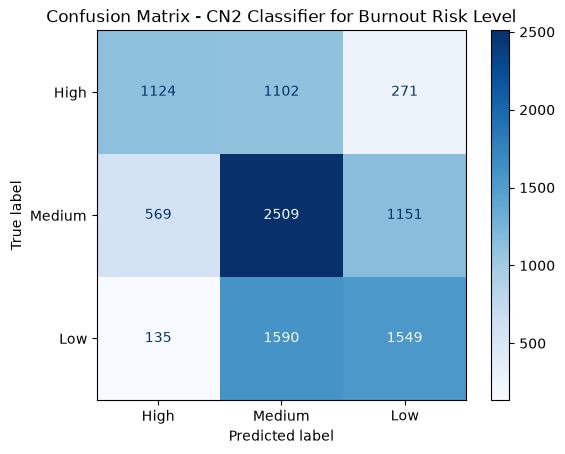

In [11]:
print("Evaluating the model...")

model_path = "models/cn2_classifier_burnout_1.pkl"

with open(model_path, 'rb') as f:
    cn2_classifier = pickle.load(f)

print(f"Model loaded: {model_path}")
print(f"Total rules: {len(cn2_classifier.rule_list)}")

raw_test_data = Orange.data.Table('database/test_dataset_burnout.csv')
test_data_sync = Orange.data.Table.from_table(cn2_classifier.domain, raw_test_data)

class_values = cn2_classifier.domain.class_var.values #['Low', 'Medium', 'High']

y_true = [class_values[int(inst.get_class())] for inst in test_data_sync]
y_pred = [class_values[int(cn2_classifier(inst))] for inst in test_data_sync]

ordered_class_values = ['High', 'Medium', 'Low']

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=ordered_class_values, target_names=ordered_class_values))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=ordered_class_values)
print(cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_class_values)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - CN2 Classifier for Burnout Risk Level")
plt.show()